In [1]:
from modules.Reinforcementlearning import SemiGradSarsa, torch, random, plt, clear_output
import torch.nn as nn
from time import sleep
import ipywidgets

In [2]:
sarsa = SemiGradSarsa()

In [3]:
class Enviroment:
    def __init__(self, left_bound, right_bound):
        self.left_bound = left_bound
        self.right_bound = right_bound
        self.x_grid = torch.linspace(left_bound, right_bound, 100)
        eps = (self.right_bound - self.left_bound) * 0.25
        self.state = torch.tensor([random.uniform(self.left_bound + eps, self.right_bound - eps), 0])

    def hill(self, x):
        xp = torch.pi * ((x - self.left_bound) / (self.right_bound - self.left_bound))
        return torch.cos(xp) ** 2

    def gravity(self, x):
        xp = torch.pi * ((x - self.left_bound) / (self.right_bound - self.left_bound))
        scale = torch.pi / (self.right_bound - self.left_bound)
        return scale * torch.cos(xp) * torch.sin(xp)

    def print(self):
        fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(8, 6))

        ax1.plot(self.x_grid, self.hill(self.x_grid))
        ax1.set_ylabel("Hill")
        ax1.grid()

        ax2.plot(self.x_grid, self.gravity(self.x_grid), color="r")
        ax2.set_ylabel("Gravity")
        ax2.set_xlabel("x")
        ax2.grid()

        plt.tight_layout()
        plt.show()

    def reset(self):
        eps = (self.right_bound - self.left_bound) * 0.25
        self.state = torch.tensor([random.uniform(self.left_bound + eps, self.right_bound - eps), 0])
        return self.state, {}
            
    def terminal_check(self):
        if self.state[0] > right_bound:
            return True
        return False
    
    def step(self, action):
        x = self.state[0]
        v = self.state[1]
        r = 0
        if v<0:
            r = 0.1
        if v>0:
            r = -0.1
        a = 0.4 * (action - 1) + self.gravity(x) + r
        xout = 0.5 * a * 0.01 + v * 0.1 + x
        vout = a * 0.1 + v
        self.state = torch.tensor([xout, vout])
        
        if xout < self.left_bound:
            self.state = torch.tensor([self.left_bound, 0.0])
            
        return self.state, -1, self.terminal_check(), False, {}
        

    def render(self, action):   
        clear_output(wait=True)
        plt.plot(self.x_grid, self.hill(self.x_grid))
        plt.plot(self.state[0], self.hill(self.state[0]), linestyle=" ", marker="o", color="r")
        a = action - 1
        if a == 1:
            plt.plot(self.state[0] + 0.02*a, self.hill(self.state[0]), linestyle=" ", marker=">", color="b")
        if a == -1:
            plt.plot(self.state[0] + 0.02*a, self.hill(self.state[0]), linestyle=" ", marker="<", color="b")
        plt.show()
        sleep(0.01)


    def test_net(self, qnet):
        try:
            while True:
                i = 0
                S, info = env.reset()
                goal_reached = False
                while not goal_reached:
                    i += 1
                    q_values = qnet(S)
                    A = torch.argmax(q_values)
                    S, R, goal_reached, trunc, info = self.step(A)
                    self.render(A)
                    sleep(0.04)
        except KeyboardInterrupt:
            pass
    

In [4]:
class Tile:
    def __init__(self, grid_size, N_grids, left_bound=-1, right_bound=1):
        self.max_index = grid_size - 1
        self.N_grids = N_grids
        self.d = 1 / N_grids
        self.scale = (right_bound - left_bound)
        self.shift = -left_bound

    def __call__(self, x):
        out = (x + self.shift) / self.scale
        out = self.max_index * out.unsqueeze(0) + (self.d * torch.arange(self.N_grids).unsqueeze(-1))
        out = torch.trunc(out).int()
        out[out > self.max_index] = self.max_index
        out[out < 0] = 0
        return torch.matmul(out, (self.max_index + 1) ** torch.arange(len(x)).int())

        
class Driver(nn.Module):
    def __init__(self, tile_grid_size, tile_N_grids, left_bound=-1, right_bound=1):
        super(Driver, self).__init__()
        self.tile = Tile(tile_grid_size, tile_N_grids, left_bound, right_bound)
        self.N_actions = 3
        self.weights = nn.Parameter(torch.zeros(tile_N_grids, tile_grid_size**2, 3, requires_grad=True))

    def forward(self, S):
        tile_rep = self.tile(S)
        out = torch.zeros(self.N_actions)
        for i, index in enumerate(tile_rep):
            out += self.weights[i, index]
        return out
        

In [5]:
left_bound = -1
right_bound = 1
driver = Driver(10,8, left_bound, right_bound)
env = Enviroment(left_bound, right_bound)

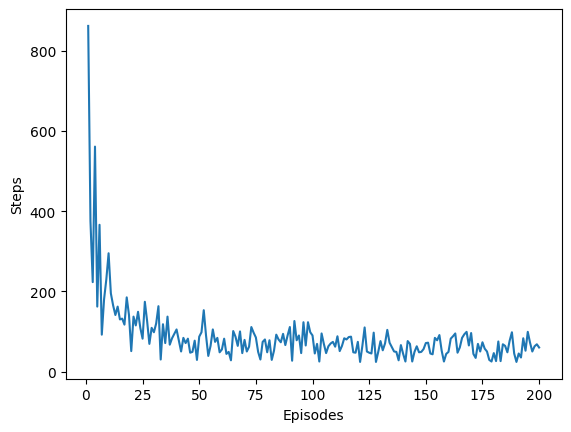

In [6]:
sarsa.run(env, driver, max_episode=1000, max_steps=1000)

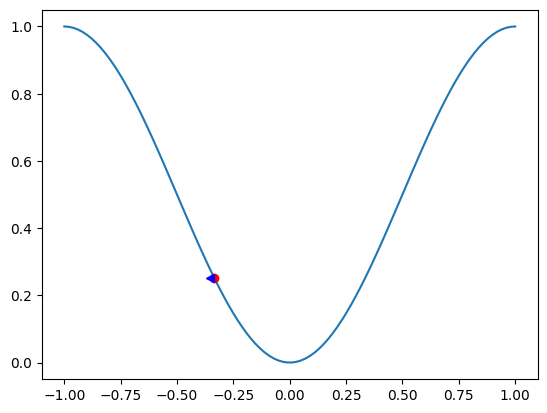

In [7]:
env.test_net(driver)